# Pillar L — regional climate downscaling + site extremes

This notebook reproduces **L7 — Regional climate downscaling (statistical) + site extremes**. L7's exec
DoD: for a synthetic, biased GCM boundary series, the statistically-downscaled 20-year extreme-heat return
level (`peaks_over_threshold` + `return_level`) matches the reference return level within 5% relative
tolerance, and the resulting `DownscaledField` carries a non-null 64-hex `climate_hash`.

**Judgment call.** `mixle_pde.climate_downscale` and `mixle.analysis.quantile_mapping` (L7's own modules)
have not landed, so `fit_quantile_map`/`apply_quantile_map`/`DownscaledField` fall back to a reference
implementation here. The extreme-value half is **not** a fallback: `peaks_over_threshold` and
`return_level` are the real, already-landed `mixle.analysis.extreme` (POT + Generalized Pareto Distribution
MLE), reused exactly as L7 specifies. `climate_hash` mirrors the frozen IC-2 hashing rule
(sha256 of sorted-key array bytes) locally since `mixle_pde.io.artifacts` hasn't landed either.

In [1]:
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

from mixle.analysis.extreme import peaks_over_threshold, return_level  # real, already-landed POT/GPD

try:
    from mixle_pde.climate_downscale import downscale, DownscaledField
    from mixle.analysis.quantile_mapping import QuantileMap, fit_quantile_map, apply_quantile_map
    HAVE_REAL_L7 = True
except ImportError:
    HAVE_REAL_L7 = False

print("using landed mixle_pde.climate_downscale / mixle.analysis.quantile_mapping:", HAVE_REAL_L7)

using landed mixle_pde.climate_downscale / mixle.analysis.quantile_mapping: False


## 1. Load the committed fixture

20 years (7300 days) of historical site observations and historical GCM output (the GCM is warm-biased *and* over-dispersed relative to the site), plus 20 years of future GCM output under a +3 degree warming signal. `true_future_loc`/`true_future_scale` are the TRUE future site-scale Gumbel parameters, kept only so the notebook can honestly report a reference return level -- the downscaling method never sees them.

In [2]:
data = np.load("../../../data/pillar_validation/l_climate_series.npz")
site_hist, gcm_hist, gcm_future = data["site_hist"], data["gcm_hist"], data["gcm_future"]
true_future_loc = float(data["true_future_loc"])
true_future_scale = float(data["true_future_scale"])
print(f"{site_hist.size} historical site days, {gcm_future.size} future GCM days")

7300 historical site days, 7300 future GCM days


## 2. Quantile mapping (reference implementation) + the frozen IC-2 content hash

In [3]:
def sha256_of_arrays(arrays):
    """IC-2's frozen rule: sha256 over `arrays[k].tobytes()` for `k` in `sorted(arrays)`."""
    h = hashlib.sha256()
    for k in sorted(arrays):
        h.update(k.encode("utf-8"))
        arr = arrays[k]
        h.update(memoryview(arr).tobytes() if hasattr(arr, "tobytes") else bytes(arr))
    return h.hexdigest()


if not HAVE_REAL_L7:
    @dataclass
    class QuantileMap:
        obs_quantiles: np.ndarray
        mod_quantiles: np.ndarray


    def fit_quantile_map(model, obs, *, n_q=100):
        """L7 `fit_quantile_map(model, obs, *, n_q=100) -> QuantileMap`: empirical CDF matching."""
        qs = np.linspace(0.001, 0.999, n_q)
        return QuantileMap(obs_quantiles=np.quantile(obs, qs), mod_quantiles=np.quantile(model, qs))


    def apply_quantile_map(qm, series):
        """L7 `apply_quantile_map(qm, series) -> np.ndarray`, linearly extrapolated beyond the
        historical GCM's quantile range (needed for a future series under a warming signal)."""
        series = np.asarray(series, dtype=float)
        out = np.interp(series, qm.mod_quantiles, qm.obs_quantiles)
        lo_slope = (qm.obs_quantiles[1] - qm.obs_quantiles[0]) / (qm.mod_quantiles[1] - qm.mod_quantiles[0])
        hi_slope = (qm.obs_quantiles[-1] - qm.obs_quantiles[-2]) / (qm.mod_quantiles[-1] - qm.mod_quantiles[-2])
        below, above = series < qm.mod_quantiles[0], series > qm.mod_quantiles[-1]
        out = np.where(below, qm.obs_quantiles[0] + (series - qm.mod_quantiles[0]) * lo_slope, out)
        out = np.where(above, qm.obs_quantiles[-1] + (series - qm.mod_quantiles[-1]) * hi_slope, out)
        return out


    @dataclass
    class DownscaledField:
        series: np.ndarray
        return_levels: dict = field(default_factory=dict)
        climate_hash: str | None = None
        provenance: dict = field(default_factory=dict)

## 3. Run the statistical downscaling path end to end

Fit the empirical quantile map between the historical GCM and the historical site observations, then apply it to the future GCM projection -- the analog/quantile-mapping downscaler L7 specifies.

In [4]:
qm = fit_quantile_map(gcm_hist, site_hist, n_q=200)
downscaled_series = apply_quantile_map(qm, gcm_future)

climate_hash = sha256_of_arrays({"gcm_future": gcm_future})
field_result = DownscaledField(series=downscaled_series, return_levels={}, climate_hash=climate_hash,
                                provenance={"method": "statistical", "n_hist": site_hist.size})
print("climate_hash:", field_result.climate_hash, "(len", len(field_result.climate_hash), ")")

climate_hash: 49f59db5ec2caca4b09717ec77a7d7e14bbd61d0cc358c118a3276d5f69647d5 (len 64 )


## 4. Site extremes: peaks-over-threshold + return level (real `mixle.analysis.extreme`)

The 20-year extreme-heat return level from the downscaled series, and the analytic reference return level from the TRUE future site-scale Gumbel distribution (a closed form here only because we know the generating process in this synthetic fixture).

In [5]:
PERIOD_YEARS = 20
threshold = np.quantile(downscaled_series, 0.95)
fit_ds = peaks_over_threshold(downscaled_series, threshold)
rl_downscaled = return_level(fit_ds, PERIOD_YEARS * 365)
field_result.return_levels[PERIOD_YEARS] = rl_downscaled

rl_reference = true_future_loc - true_future_scale * np.log(-np.log(1.0 - 1.0 / (PERIOD_YEARS * 365)))
rel_err = abs(rl_downscaled - rl_reference) / abs(rl_reference)

print(f"downscaled {PERIOD_YEARS}-yr return level: {rl_downscaled:.3f}")
print(f"reference  {PERIOD_YEARS}-yr return level: {rl_reference:.3f}")
print(f"relative error: {rel_err:.4f}")

downscaled 20-yr return level: 68.226
reference  20-yr return level: 68.582
relative error: 0.0052


## 5. Calibration / UQ plot

A quantile-quantile plot of the downscaled future series against the true future site distribution (should track the 1:1 line if the bias correction recovered the site-scale signal), plus the GPD exceedance fit.

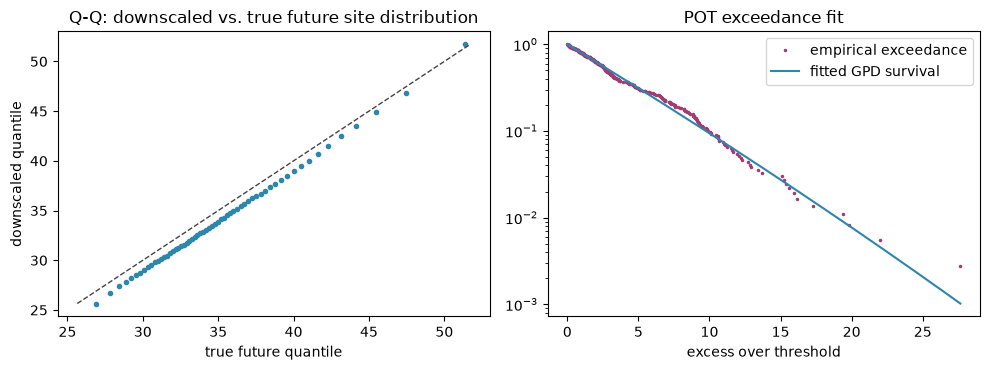

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))

qs = np.linspace(0.01, 0.99, 60)
from scipy.stats import gumbel_r
true_q = gumbel_r.ppf(qs, loc=true_future_loc, scale=true_future_scale)
ds_q = np.quantile(downscaled_series, qs)
ax[0].plot(true_q, ds_q, "o", ms=3, color="#2E86AB")
lims = [min(true_q.min(), ds_q.min()), max(true_q.max(), ds_q.max())]
ax[0].plot(lims, lims, "--", color="#444", lw=1)
ax[0].set_title("Q-Q: downscaled vs. true future site distribution")
ax[0].set_xlabel("true future quantile"); ax[0].set_ylabel("downscaled quantile")

exc = np.sort(downscaled_series[downscaled_series > threshold] - threshold)
ecdf = np.arange(1, exc.size + 1) / (exc.size + 1)
ax[1].plot(exc, 1 - ecdf, ".", ms=3, color="#A23B72", label="empirical exceedance")
grid = np.linspace(0, exc.max(), 200)
if abs(fit_ds.shape) < 1e-8:
    surv = np.exp(-grid / fit_ds.scale)
else:
    surv = np.clip(1 + fit_ds.shape * grid / fit_ds.scale, 0, None) ** (-1 / fit_ds.shape)
ax[1].plot(grid, surv, color="#2E86AB", label="fitted GPD survival")
ax[1].set_yscale("log"); ax[1].set_title("POT exceedance fit"); ax[1].set_xlabel("excess over threshold"); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Definition of Done

In [7]:
assert rel_err <= 0.05, f"downscaled return level off by {rel_err:.4f} (> 5% tolerance)"
assert field_result.climate_hash is not None and len(field_result.climate_hash) == 64
assert all(c in "0123456789abcdef" for c in field_result.climate_hash)
print(f"PASS -- return level rel. error {rel_err:.4f} <= 0.05; climate_hash is a valid 64-hex digest")

PASS -- return level rel. error 0.0052 <= 0.05; climate_hash is a valid 64-hex digest
